# 📊 H&M 추천 시스템 — 대시보드 & 시각화

## 이 노트북의 역할

> **3개 핵심 이해관계자 대시보드를 Python으로 직접 시각화 & CSV 내보내기**

| # | 대시보드 | 타겟 | 핵심 메시지 |
|---|---------|------|------------|
| 1 | 경영진 대시보드 | C-Level | 매출 트렌드, 채널 전략, KPI |
| 2 | MD팀 상품 분석 | 머천다이저 | 파레토, 수명주기, Cold Start |
| 3 | CRM팀 고객 분석 | 마케터 | 활성도, RFM 페르소나, 채널 선호도 |
| 4 | 모델 성능 | 데이터팀/경영진 | GNN vs 베이스라인 (GNN 실행 후 업데이트) |

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import os, warnings
warnings.filterwarnings('ignore')

import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH   = '../Data Folder/H&M dataset/H&m parquet dataset'
ART_CSV     = '../Data Folder/H&M dataset/H&M CSV dataset/articles.csv'
EXPORT_PATH = '../Data Folder/dashboard'
os.makedirs(EXPORT_PATH, exist_ok=True)

transactions = pd.read_parquet(f'{DATA_PATH}/transactions.parquet')
customers    = pd.read_parquet(f'{DATA_PATH}/customers.parquet')
art_csv      = pd.read_csv(ART_CSV, usecols=['article_id','prod_name',
                            'product_group_name','index_group_name','colour_group_name'])

transactions['t_dat']      = pd.to_datetime(transactions['t_dat'])
transactions['price_krw']  = (transactions['price'] * 590 * 1314).round(0).astype(int)
transactions['year_month'] = transactions['t_dat'].dt.to_period('M')

print(f'거래: {len(transactions):,}건 | 고객: {len(customers):,}명')
print(f'기간: {transactions["t_dat"].min().date()} ~ {transactions["t_dat"].max().date()}')

거래: 31,097,423건 | 고객: 1,356,119명
기간: 2018-09-20 ~ 2020-09-22


---

## Dashboard 1 — 경영진 대시보드 (Executive)

> 매출 트렌드, 채널 전략, 핵심 KPI를 한눈에

---

fact_transactions.csv 저장: 49행


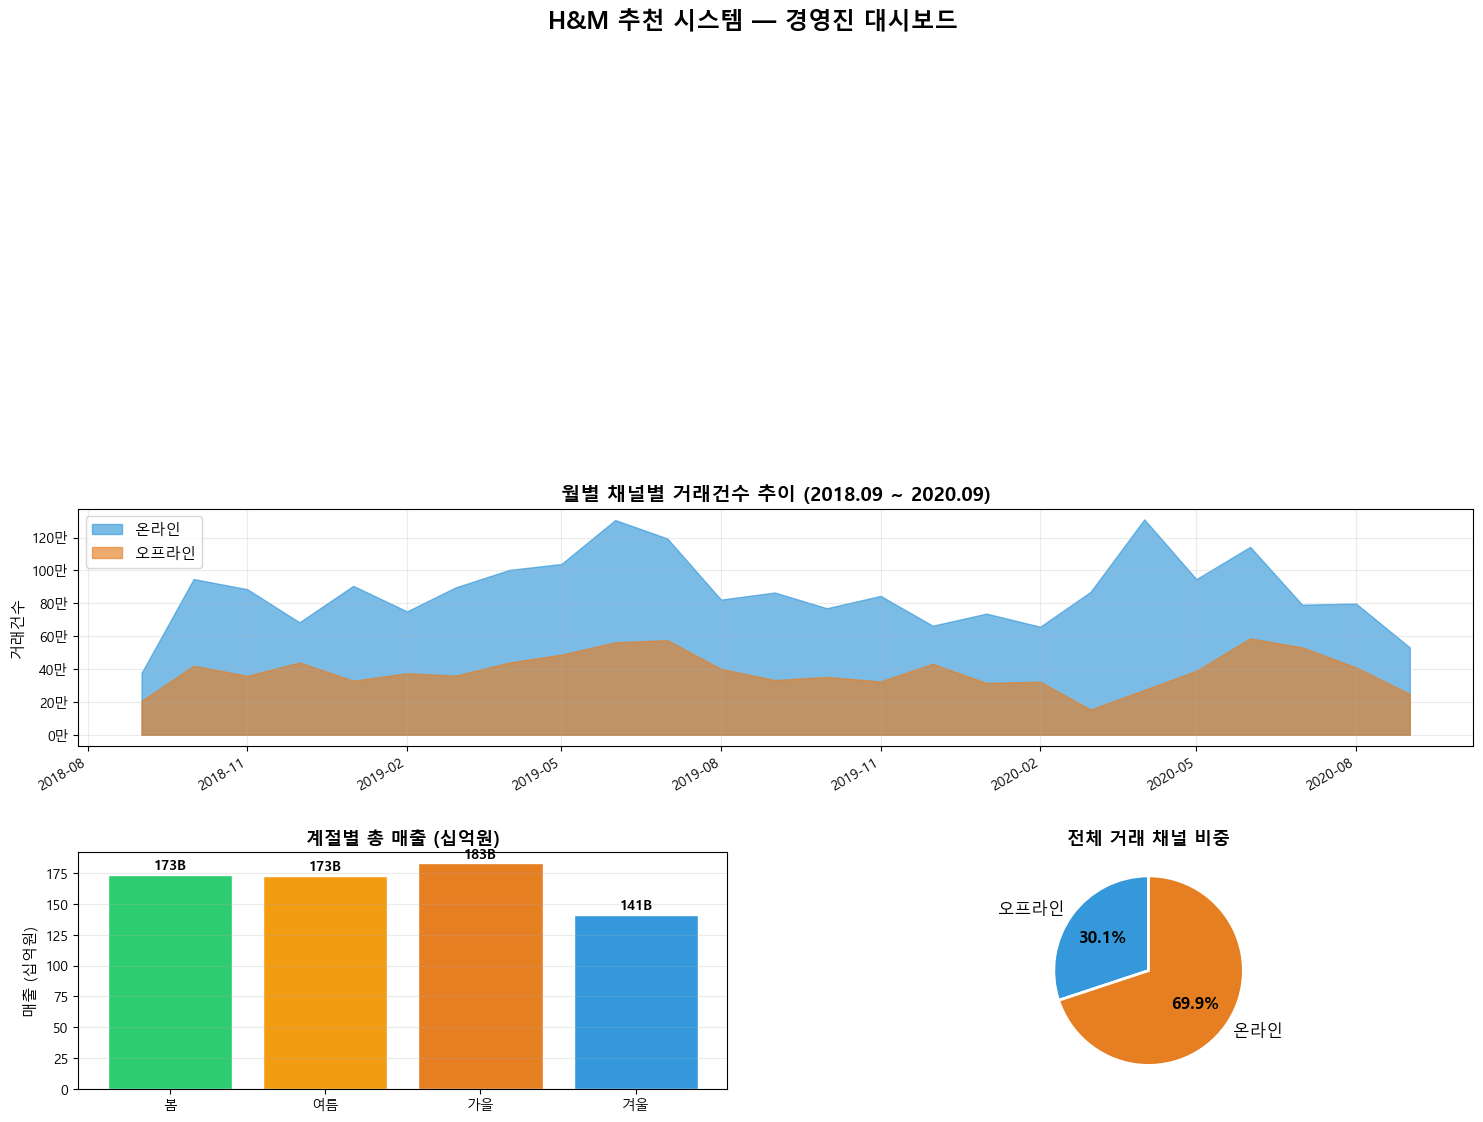

Dashboard 1 완료


In [2]:
# ──────────────────────────────────────────────────────
# CSV: fact_transactions.csv
# ──────────────────────────────────────────────────────
monthly_ch = (transactions.groupby(['year_month', 'sales_channel_id'])
    .agg(txn_count        =('customer_id', 'count'),
         unique_customers =('customer_id', 'nunique'),
         unique_products  =('article_id',  'nunique'),
         total_revenue_krw=('price_krw',   'sum'),
         avg_price_krw    =('price_krw',   'mean'))
    .reset_index())
monthly_ch['year_month']    = monthly_ch['year_month'].dt.to_timestamp()
monthly_ch['channel']       = monthly_ch['sales_channel_id'].map({1:'오프라인', 2:'온라인'})
monthly_ch['avg_price_krw'] = monthly_ch['avg_price_krw'].round(0).astype(int)
monthly_ch['season']        = monthly_ch['year_month'].dt.month.map(
    {12:'겨울',1:'겨울',2:'겨울',3:'봄',4:'봄',5:'봄',
     6:'여름',7:'여름',8:'여름',9:'가을',10:'가을',11:'가을'})
monthly_ch.to_csv(f'{EXPORT_PATH}/fact_transactions.csv', index=False, encoding='utf-8-sig')
print(f'fact_transactions.csv 저장: {len(monthly_ch)}행')

# ──────────────────────────────────────────────────────
# CHART
# ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# KPI 카드
kpi_configs = [
    ('총 거래건수',   f'{len(transactions):,}건',           '#2ECC71', '2018~2020 누적'),
    ('총 고객수',     f'{customers["customer_id"].nunique():,}명', '#3498DB', '활성 고객'),
    ('1개월 재구매율','17.4%',                               '#E74C3C', '업계평균 25~35% 대비 낮음'),
    ('그래프 희소성', '99.98%',                              '#9B59B6', 'GNN 필요성 근거'),
]
for i, (title, value, color, sub) in enumerate(kpi_configs):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(color)
    ax.text(0.5, 0.65, value,  transform=ax.transAxes, fontsize=20,
            ha='center', va='center', fontweight='bold', color='white')
    ax.text(0.5, 0.30, title,  transform=ax.transAxes, fontsize=11,
            ha='center', va='center', color='white', fontweight='bold')
    ax.text(0.5, 0.10, sub,    transform=ax.transAxes, fontsize=8.5,
            ha='center', va='center', color='white', alpha=0.85)
    ax.axis('off')

# 월별 채널별 거래건수
ax2 = fig.add_subplot(gs[1, :])
online  = monthly_ch[monthly_ch['channel']=='온라인'].set_index('year_month')['txn_count']
offline = monthly_ch[monthly_ch['channel']=='오프라인'].set_index('year_month')['txn_count']
ax2.fill_between(online.index,  online.values,  alpha=0.65, color='#3498DB', label='온라인')
ax2.fill_between(offline.index, offline.values, alpha=0.65, color='#E67E22', label='오프라인')
ax2.set_title('월별 채널별 거래건수 추이 (2018.09 ~ 2020.09)', fontsize=14, fontweight='bold')
ax2.set_ylabel('거래건수', fontsize=11)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax2.legend(fontsize=11, loc='upper left')
ax2.grid(True, alpha=0.25)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e4:.0f}만'))

# 계절별 매출
ax3 = fig.add_subplot(gs[2, :2])
season_data = (monthly_ch.groupby('season')['total_revenue_krw'].sum()
               .reindex(['봄','여름','가을','겨울']))
colors_s = ['#2ECC71','#F39C12','#E67E22','#3498DB']
bars3 = ax3.bar(season_data.index, season_data.values/1e9, color=colors_s, edgecolor='white')
ax3.set_title('계절별 총 매출 (십억원)', fontsize=13, fontweight='bold')
ax3.set_ylabel('매출 (십억원)', fontsize=11)
ax3.grid(True, alpha=0.25, axis='y')
for b in bars3:
    ax3.annotate(f'{b.get_height():.0f}B',
                 xy=(b.get_x()+b.get_width()/2, b.get_height()),
                 xytext=(0,4), textcoords='offset points', ha='center', fontsize=10, fontweight='bold')

# 채널 비중 파이
ax4 = fig.add_subplot(gs[2, 2:])
ch_total = monthly_ch.groupby('channel')['txn_count'].sum()
wedges, texts, autotexts = ax4.pie(
    ch_total.values, labels=ch_total.index, autopct='%1.1f%%',
    colors=['#3498DB','#E67E22'], startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':12})
for at in autotexts: at.set_fontsize(12); at.set_fontweight('bold')
ax4.set_title('전체 거래 채널 비중', fontsize=13, fontweight='bold')

plt.suptitle('H&M 추천 시스템 — 경영진 대시보드', fontsize=17, fontweight='bold', y=1.01)
plt.savefig(f'{EXPORT_PATH}/dashboard_01_executive.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard 1 완료')

---

## Dashboard 2 — MD팀 상품 분석 대시보드

> 파레토 분석, Star vs Long-tail 궤적, 가격 등급, 카테고리 성과

---

dim_products.csv 저장: 104,400행


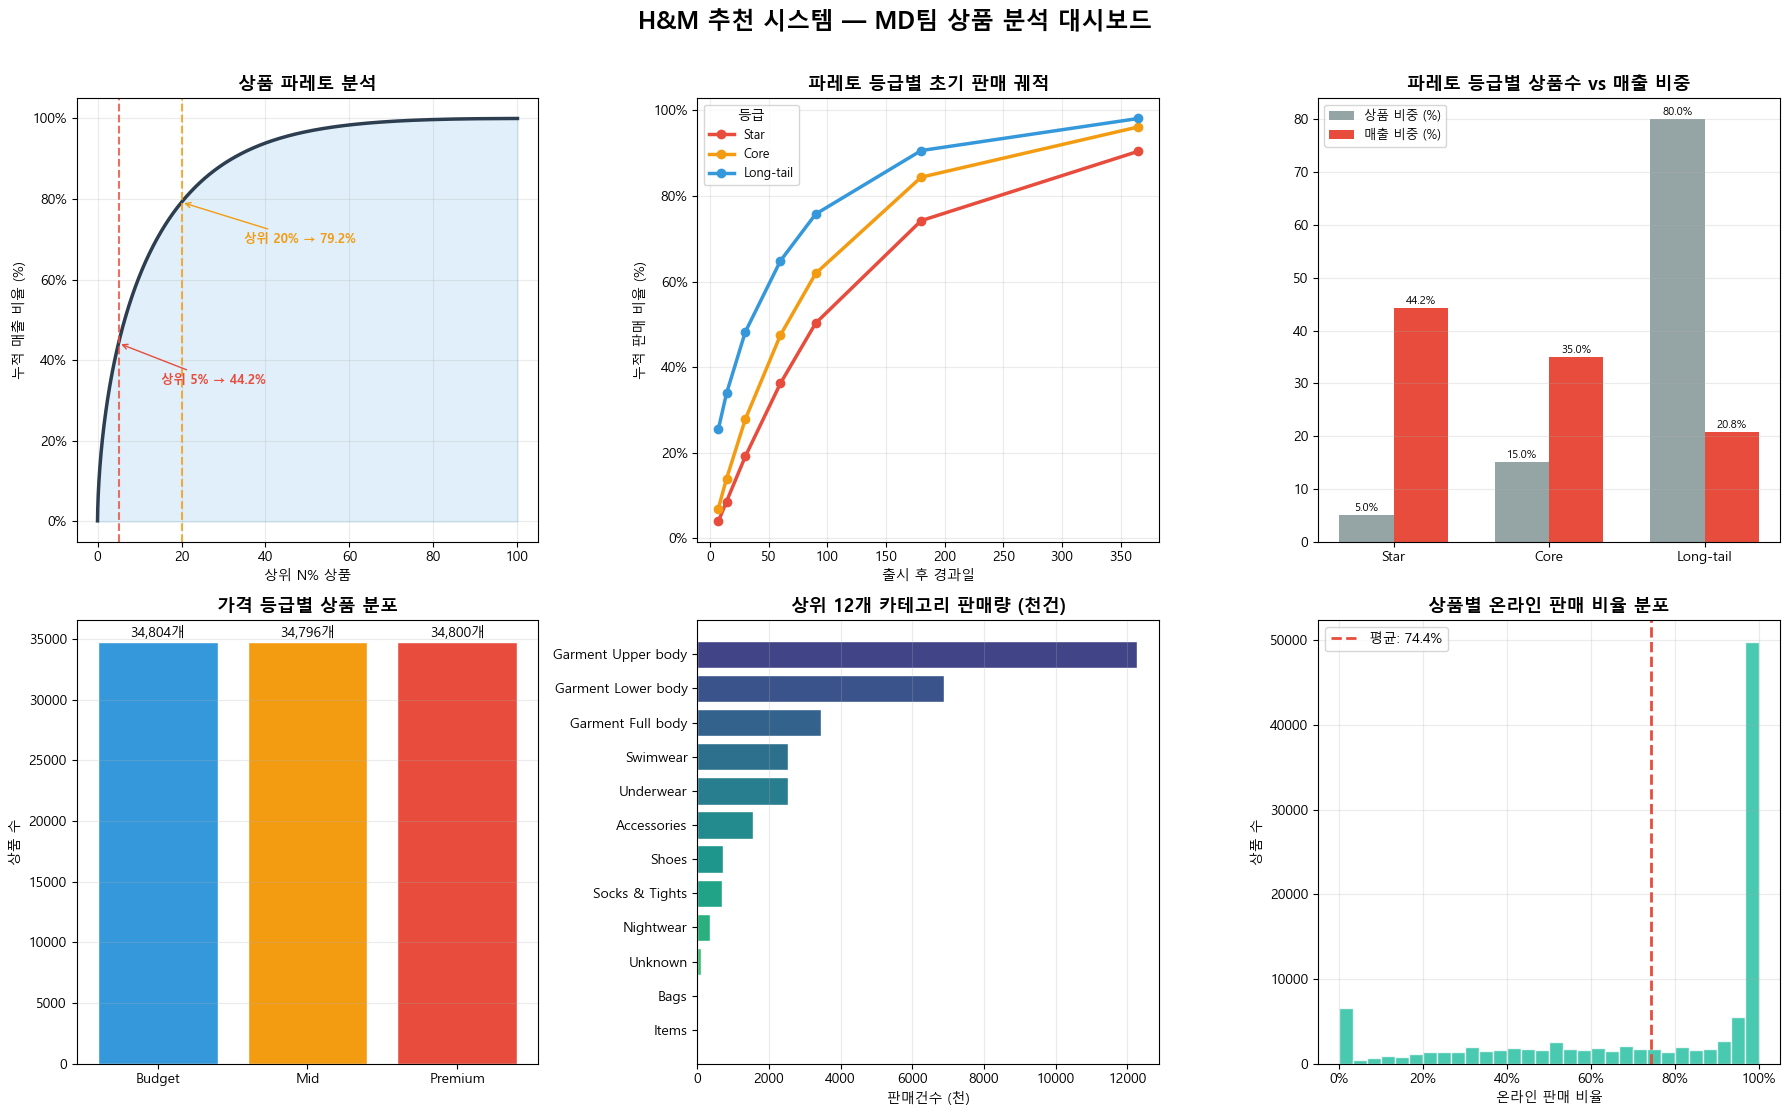

Dashboard 2 완료


In [3]:
# ──────────────────────────────────────────────────────
# CSV: dim_products.csv
# ──────────────────────────────────────────────────────
item_stats = transactions.groupby('article_id').agg(
    total_sales  =('customer_id','count'),
    unique_buyers=('customer_id','nunique'),
    online_ratio =('sales_channel_id', lambda x: round((x==2).mean(), 3)),
    avg_price_krw=('price_krw','mean')
).reset_index()
item_stats['avg_price_krw'] = item_stats['avg_price_krw'].round(0).astype(int)
n = len(item_stats)
item_stats = item_stats.sort_values('total_sales', ascending=False).reset_index(drop=True)
item_stats['item_rank_pct'] = (item_stats.index + 1) / n * 100
item_stats['cum_sales_pct'] = item_stats['total_sales'].cumsum() / item_stats['total_sales'].sum() * 100
item_stats['pareto_tier']   = 'Long-tail'
item_stats.loc[item_stats['item_rank_pct'] <= 5,  'pareto_tier'] = 'Star'
item_stats.loc[(item_stats['item_rank_pct']>5) & (item_stats['item_rank_pct']<=20), 'pareto_tier'] = 'Core'
item_stats['price_tier'] = pd.qcut(item_stats['avg_price_krw'].fillna(0),
                                   q=3, labels=['Budget','Mid','Premium'])
item_stats = item_stats.merge(art_csv, on='article_id', how='left')
item_stats.to_csv(f'{EXPORT_PATH}/dim_products.csv', index=False, encoding='utf-8-sig')
print(f'dim_products.csv 저장: {len(item_stats):,}행')

# Star vs Long-tail 궤적
first_sale = transactions.groupby('article_id')['t_dat'].min().rename('first_sale_date')
trx_lc = transactions.merge(first_sale, on='article_id')
trx_lc['days_since_launch'] = (trx_lc['t_dat'] - trx_lc['first_sale_date']).dt.days
trx_lc = trx_lc.merge(item_stats[['article_id','pareto_tier']], on='article_id')
traj_rows = []
for tier in ['Star','Core','Long-tail']:
    td = trx_lc[trx_lc['pareto_tier']==tier]
    for w in [7,14,30,60,90,180,365]:
        s = td[td['days_since_launch']<=w].groupby('article_id').size()
        t = td.groupby('article_id').size()
        traj_rows.append({'pareto_tier':tier,'days':w,
                          'cum_sales_pct':round((s/t).fillna(0).mean()*100,2)})
traj = pd.DataFrame(traj_rows)

# ──────────────────────────────────────────────────────
# CHART
# ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('H&M 추천 시스템 — MD팀 상품 분석 대시보드', fontsize=17, fontweight='bold', y=1.01)

# 파레토 곡선
ax = axes[0,0]
ax.plot(item_stats['item_rank_pct'], item_stats['cum_sales_pct'],
        color='#2C3E50', linewidth=2.5)
ax.fill_between(item_stats['item_rank_pct'], item_stats['cum_sales_pct'], alpha=0.15, color='#3498DB')
top5  = item_stats[item_stats['item_rank_pct']<=5]['total_sales'].sum()  / item_stats['total_sales'].sum()*100
top20 = item_stats[item_stats['item_rank_pct']<=20]['total_sales'].sum() / item_stats['total_sales'].sum()*100
ax.axvline(5,  color='#E74C3C', linestyle='--', alpha=0.8)
ax.axvline(20, color='#F39C12', linestyle='--', alpha=0.8)
ax.annotate(f'상위 5% → {top5:.1f}%',  xy=(5, top5),  xytext=(15, top5-10),
            fontsize=9, color='#E74C3C', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#E74C3C'))
ax.annotate(f'상위 20% → {top20:.1f}%', xy=(20, top20), xytext=(35, top20-10),
            fontsize=9, color='#F39C12', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#F39C12'))
ax.set_title('상품 파레토 분석', fontsize=13, fontweight='bold')
ax.set_xlabel('상위 N% 상품', fontsize=10); ax.set_ylabel('누적 매출 비율 (%)', fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(True, alpha=0.25)

# Star vs Long-tail 궤적
ax = axes[0,1]
colors_t = {'Star':'#E74C3C','Core':'#F39C12','Long-tail':'#3498DB'}
for tier in ['Star','Core','Long-tail']:
    d = traj[traj['pareto_tier']==tier]
    ax.plot(d['days'], d['cum_sales_pct'], marker='o', linewidth=2.5,
            label=tier, color=colors_t[tier])
ax.set_title('파레토 등급별 초기 판매 궤적', fontsize=13, fontweight='bold')
ax.set_xlabel('출시 후 경과일', fontsize=10); ax.set_ylabel('누적 판매 비율 (%)', fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='등급', fontsize=9); ax.grid(True, alpha=0.25)

# 파레토 등급별 상품수 vs 매출
ax = axes[0,2]
tier_s = item_stats.groupby('pareto_tier').agg(
    item_count=('article_id','count'), total_sales=('total_sales','sum')).reset_index()
tier_s['sales_pct'] = tier_s['total_sales']/tier_s['total_sales'].sum()*100
tier_s['item_pct']  = tier_s['item_count'] /tier_s['item_count'].sum()*100
order = ['Star','Core','Long-tail']
tier_s = tier_s.set_index('pareto_tier').reindex(order).reset_index()
x = range(len(tier_s)); w = 0.35
b1 = ax.bar([xi-w/2 for xi in x], tier_s['item_pct'],  w, label='상품 비중 (%)', color='#95A5A6')
b2 = ax.bar([xi+w/2 for xi in x], tier_s['sales_pct'], w, label='매출 비중 (%)', color='#E74C3C')
ax.set_xticks(list(x)); ax.set_xticklabels(order, fontsize=10)
ax.set_title('파레토 등급별 상품수 vs 매출 비중', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.25, axis='y')
for b in list(b1)+list(b2):
    ax.annotate(f'{b.get_height():.1f}%',
                xy=(b.get_x()+b.get_width()/2, b.get_height()),
                xytext=(0,3), textcoords='offset points', ha='center', fontsize=8)

# 가격 등급별
ax = axes[1,0]
pt = item_stats['price_tier'].value_counts().reindex(['Budget','Mid','Premium'])
bars_pt = ax.bar(pt.index, pt.values, color=['#3498DB','#F39C12','#E74C3C'], edgecolor='white')
ax.set_title('가격 등급별 상품 분포', fontsize=13, fontweight='bold')
ax.set_ylabel('상품 수', fontsize=10); ax.grid(True, alpha=0.25, axis='y')
for b in bars_pt:
    ax.annotate(f'{b.get_height():,}개',
                xy=(b.get_x()+b.get_width()/2, b.get_height()),
                xytext=(0,3), textcoords='offset points', ha='center', fontsize=10)

# 상위 카테고리
ax = axes[1,1]
cat_s = (item_stats.groupby('product_group_name')['total_sales']
         .sum().sort_values(ascending=False).head(12))
ax.barh(cat_s.index[::-1], cat_s.values[::-1]/1e3,
        color=plt.cm.viridis_r(np.linspace(0.2,0.8,len(cat_s))), edgecolor='white')
ax.set_title('상위 12개 카테고리 판매량 (천건)', fontsize=13, fontweight='bold')
ax.set_xlabel('판매건수 (천)', fontsize=10); ax.grid(True, alpha=0.25, axis='x')

# 온라인 비율 분포
ax = axes[1,2]
ax.hist(item_stats['online_ratio'], bins=30, color='#1ABC9C', edgecolor='white', alpha=0.8)
ax.axvline(item_stats['online_ratio'].mean(), color='#E74C3C', linestyle='--', linewidth=2,
           label=f'평균: {item_stats["online_ratio"].mean():.1%}')
ax.set_title('상품별 온라인 판매 비율 분포', fontsize=13, fontweight='bold')
ax.set_xlabel('온라인 판매 비율', fontsize=10); ax.set_ylabel('상품 수', fontsize=10)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend(fontsize=10); ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(f'{EXPORT_PATH}/dashboard_02_products.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard 2 완료')

---

## Dashboard 3 — CRM팀 고객 분석 대시보드

> 활성도 퍼널, RFM 페르소나, 연령대별 구매 패턴, 채널 선호도

---

dim_customers.csv 저장: 1,360,919행


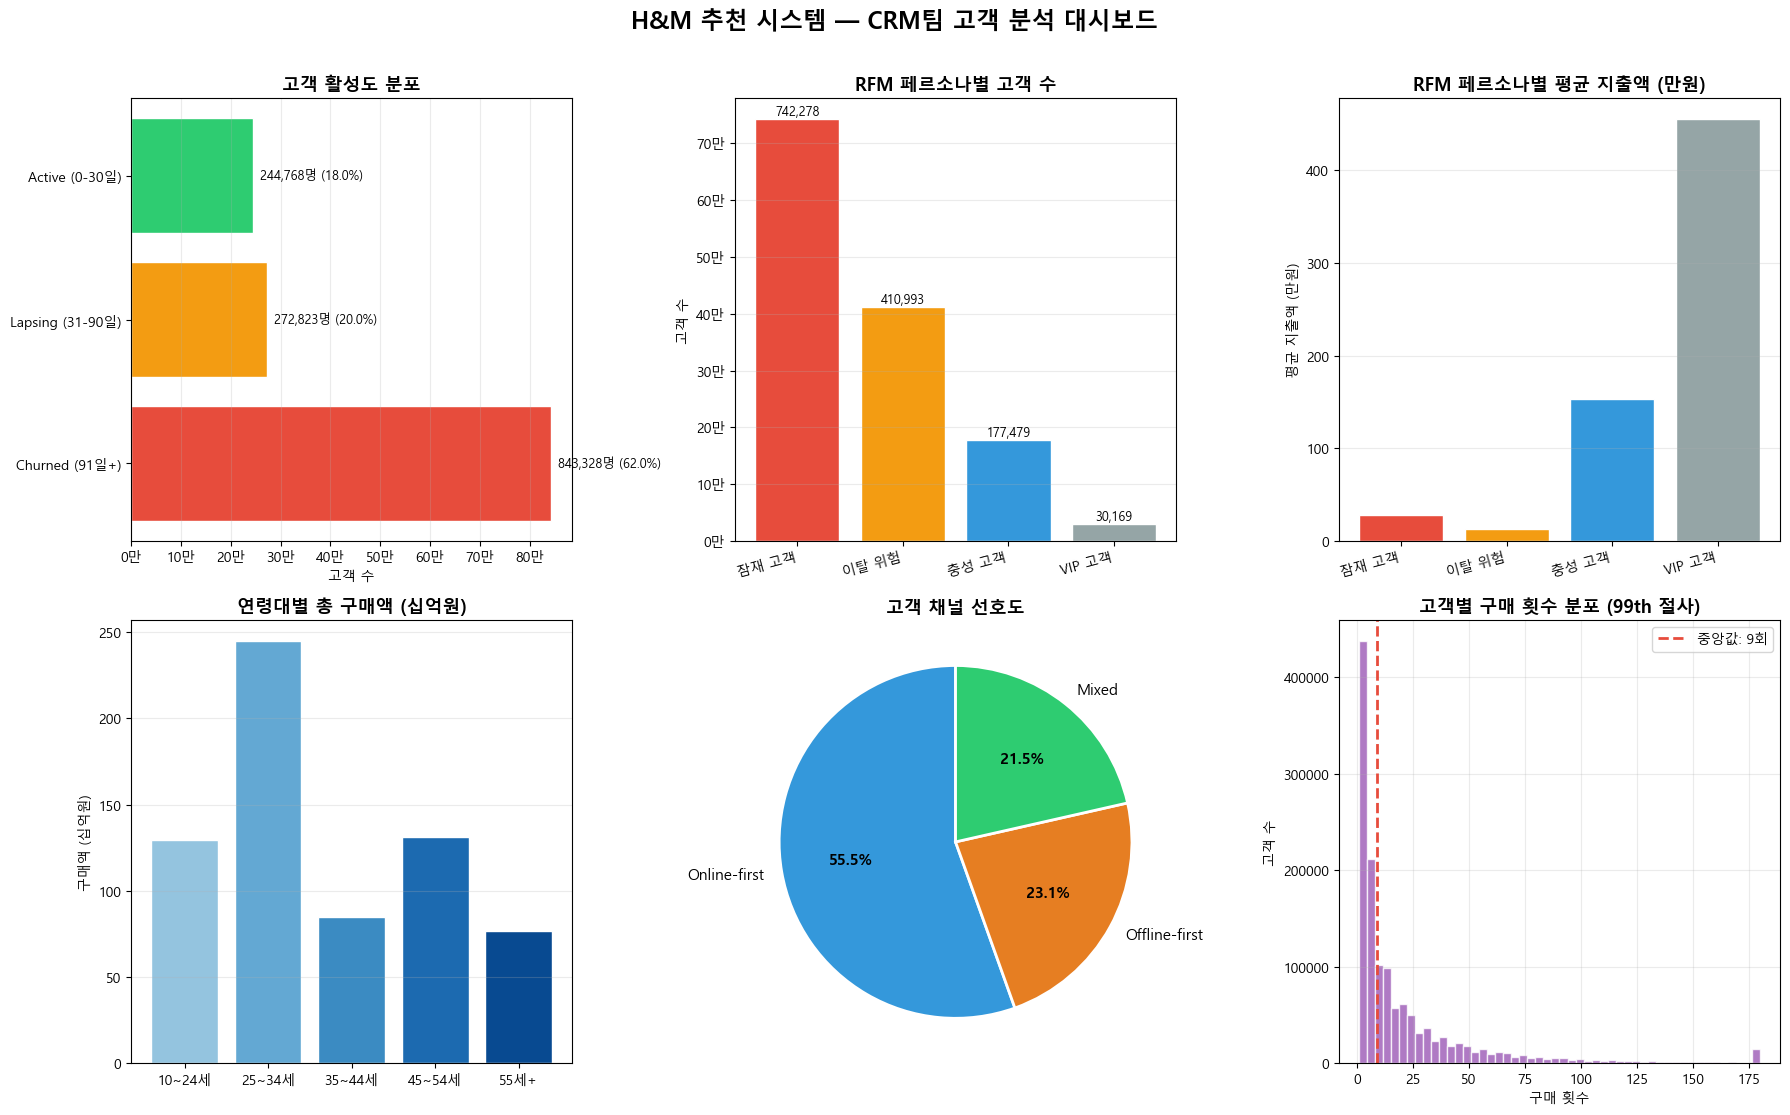

Dashboard 3 완료


In [4]:
# ──────────────────────────────────────────────────────
# CSV: dim_customers.csv
# ──────────────────────────────────────────────────────
ref_date  = transactions['t_dat'].max() + pd.Timedelta(days=1)
cus_stats = transactions.groupby('customer_id').agg(
    last_purchase   =('t_dat',   'max'),
    first_purchase  =('t_dat',   'min'),
    total_purchases =('article_id','count'),
    total_spend_krw =('price_krw', 'sum'),
    online_count    =('sales_channel_id', lambda x: (x==2).sum())
).reset_index()
cus_stats['recency_days']        = (ref_date - cus_stats['last_purchase']).dt.days
cus_stats['avg_order_value']     = (cus_stats['total_spend_krw'] / cus_stats['total_purchases']).round(0)
cus_stats['channel_pref_online'] = (cus_stats['online_count'] / cus_stats['total_purchases']).round(3)
cus_stats['activity_level'] = 'Churned (91일+)'
cus_stats.loc[cus_stats['recency_days']<=90, 'activity_level'] = 'Lapsing (31-90일)'
cus_stats.loc[cus_stats['recency_days']<=30, 'activity_level'] = 'Active (0-30일)'

cus_stats['R_score'] = pd.qcut(cus_stats['recency_days'], 5, labels=[5,4,3,2,1]).astype(int)
cus_stats['F_score'] = pd.qcut(cus_stats['total_purchases'].clip(
    upper=cus_stats['total_purchases'].quantile(0.99)), 5, labels=[1,2,3,4,5], duplicates='drop').astype(int)
cus_stats['M_score'] = pd.qcut(cus_stats['total_spend_krw'].clip(
    upper=cus_stats['total_spend_krw'].quantile(0.99)), 5, labels=[1,2,3,4,5], duplicates='drop').astype(int)

rfm_n = StandardScaler().fit_transform(cus_stats[['recency_days','total_purchases','total_spend_krw']])
cus_stats['rfm_cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(rfm_n)
cs = cus_stats.groupby('rfm_cluster')['total_spend_krw'].mean().sort_values(ascending=False)
pm = {c:n for c,n in zip(cs.index, ['VIP 고객','충성 고객','잠재 고객','이탈 위험'])}
cus_stats['rfm_persona'] = cus_stats['rfm_cluster'].map(pm)

cus_age = customers[['customer_id','age']].dropna()
cus_age['age_group'] = pd.cut(cus_age['age'], bins=[0,24,34,44,54,100],
    labels=['10~24세','25~34세','35~44세','45~54세','55세+']).astype(str)
cus_stats = cus_stats.merge(cus_age, on='customer_id', how='left')
cus_stats['channel_preference'] = 'Mixed'
cus_stats.loc[cus_stats['channel_pref_online'] > 0.8, 'channel_preference'] = 'Online-first'
cus_stats.loc[cus_stats['channel_pref_online'] < 0.2, 'channel_preference'] = 'Offline-first'
cus_stats['gnn_persona']      = None
cus_stats['gnn_style_cluster']= None
cus_stats['last_purchase']    = cus_stats['last_purchase'].dt.date
cus_stats.to_csv(f'{EXPORT_PATH}/dim_customers.csv', index=False, encoding='utf-8-sig')
print(f'dim_customers.csv 저장: {len(cus_stats):,}행')

# ──────────────────────────────────────────────────────
# CHART
# ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('H&M 추천 시스템 — CRM팀 고객 분석 대시보드', fontsize=17, fontweight='bold', y=1.01)

# 활성도 퍼널
ax = axes[0,0]
labels_a = ['Active (0-30일)', 'Lapsing (31-90일)', 'Churned (91일+)']
colors_a = ['#2ECC71','#F39C12','#E74C3C']
act_ct   = cus_stats['activity_level'].value_counts()
vals_a   = [act_ct.get(l, 0) for l in labels_a]
bars_a   = ax.barh(labels_a[::-1], vals_a[::-1], color=colors_a[::-1], edgecolor='white')
ax.set_title('고객 활성도 분포', fontsize=13, fontweight='bold')
ax.set_xlabel('고객 수', fontsize=10)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e4:.0f}만'))
ax.grid(True, alpha=0.25, axis='x')
for b, v in zip(bars_a, vals_a[::-1]):
    ax.annotate(f'{v:,}명 ({v/len(cus_stats)*100:.1f}%)',
                xy=(b.get_width(), b.get_y()+b.get_height()/2),
                xytext=(5,0), textcoords='offset points', va='center', fontsize=9)

# RFM 페르소나별 고객수
ax = axes[0,1]
p_ct  = cus_stats['rfm_persona'].value_counts()
cp    = ['#E74C3C','#F39C12','#3498DB','#95A5A6']
bars_p = ax.bar(p_ct.index, p_ct.values, color=cp[:len(p_ct)], edgecolor='white')
ax.set_title('RFM 페르소나별 고객 수', fontsize=13, fontweight='bold')
ax.set_ylabel('고객 수', fontsize=10); ax.grid(True, alpha=0.25, axis='y')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e4:.0f}만'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')
for b in bars_p:
    ax.annotate(f'{b.get_height():,}',
                xy=(b.get_x()+b.get_width()/2, b.get_height()),
                xytext=(0,3), textcoords='offset points', ha='center', fontsize=9)

# RFM 페르소나별 평균 지출
ax = axes[0,2]
p_rev = cus_stats.groupby('rfm_persona')['total_spend_krw'].mean().reindex(p_ct.index)
ax.bar(p_rev.index, p_rev.values/1e4, color=cp[:len(p_rev)], edgecolor='white')
ax.set_title('RFM 페르소나별 평균 지출액 (만원)', fontsize=13, fontweight='bold')
ax.set_ylabel('평균 지출액 (만원)', fontsize=10); ax.grid(True, alpha=0.25, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')

# 연령대별 구매액
ax = axes[1,0]
age_trx = (transactions
    .merge(cus_age[['customer_id','age_group']], on='customer_id', how='left')
    .groupby('age_group')['price_krw'].sum()
    .reindex(['10~24세','25~34세','35~44세','45~54세','55세+']))
ax.bar(age_trx.index, age_trx.values/1e9,
       color=plt.cm.Blues(np.linspace(0.4,0.9,len(age_trx))), edgecolor='white')
ax.set_title('연령대별 총 구매액 (십억원)', fontsize=13, fontweight='bold')
ax.set_ylabel('구매액 (십억원)', fontsize=10); ax.grid(True, alpha=0.25, axis='y')

# 채널 선호도 파이
ax = axes[1,1]
ch_p = cus_stats['channel_preference'].value_counts()
wedges, texts, auts = ax.pie(
    ch_p.values, labels=ch_p.index, autopct='%1.1f%%',
    colors=['#3498DB','#E67E22','#2ECC71'], startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':11})
for at in auts: at.set_fontsize(11); at.set_fontweight('bold')
ax.set_title('고객 채널 선호도', fontsize=13, fontweight='bold')

# 구매 빈도 분포
ax = axes[1,2]
freq_c = cus_stats['total_purchases'].clip(upper=cus_stats['total_purchases'].quantile(0.99))
ax.hist(freq_c, bins=50, color='#9B59B6', edgecolor='white', alpha=0.8)
ax.axvline(cus_stats['total_purchases'].median(), color='#E74C3C', linestyle='--', linewidth=2,
           label=f'중앙값: {cus_stats["total_purchases"].median():.0f}회')
ax.set_title('고객별 구매 횟수 분포 (99th 절사)', fontsize=13, fontweight='bold')
ax.set_xlabel('구매 횟수', fontsize=10); ax.set_ylabel('고객 수', fontsize=10)
ax.legend(fontsize=10); ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(f'{EXPORT_PATH}/dashboard_03_customers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard 3 완료')

---

## Dashboard 4 — 모델 성능 대시보드

> `04_GNN_모델링.ipynb`를 먼저 실행하면 GNN 수치가 자동으로 채워집니다.

---

kpi_master.csv 저장 완료


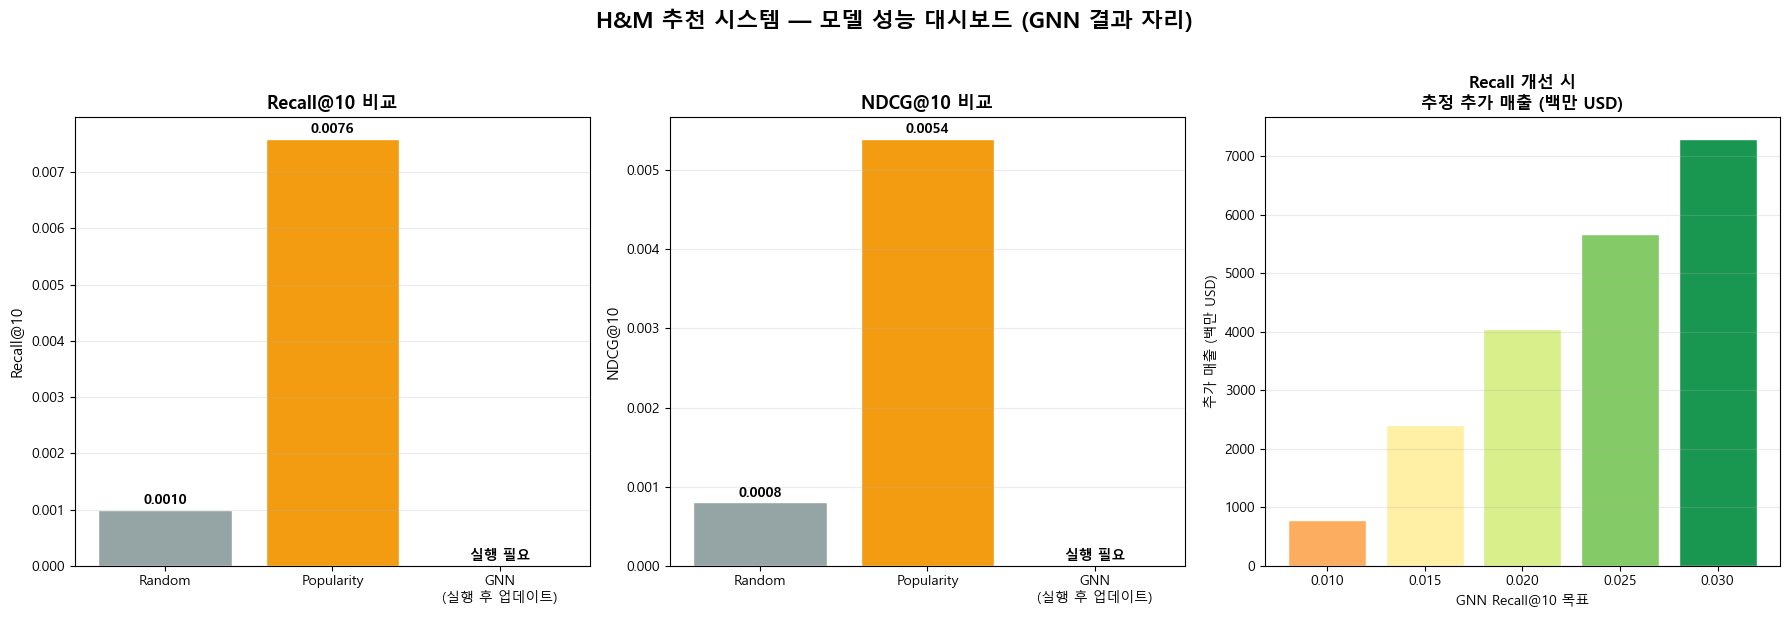

Dashboard 4 완료


In [5]:
# ──────────────────────────────────────────────────────
# CSV: kpi_master.csv
# ──────────────────────────────────────────────────────
n_u = len(cus_stats)
n_i = len(item_stats)
n_t = len(transactions)
top5_pct = round(item_stats[item_stats['item_rank_pct']<=5]['total_sales'].sum()
                 / item_stats['total_sales'].sum() * 100, 1)
act_c = int((cus_stats['activity_level']=='Active (0-30일)').sum())
lap_c = int((cus_stats['activity_level']=='Lapsing (31-90일)').sum())
chu_c = int((cus_stats['activity_level']=='Churned (91일+)').sum())

kpi_df = pd.DataFrame([
    {'category':'데이터',    'metric':'총 거래건수',       'value':n_t,   'unit':'건',  'source':'H&M Kaggle'},
    {'category':'데이터',    'metric':'총 고객수',         'value':n_u,   'unit':'명',  'source':'H&M Kaggle'},
    {'category':'데이터',    'metric':'총 상품수',         'value':n_i,   'unit':'개',  'source':'H&M Kaggle'},
    {'category':'비즈니스',  'metric':'파레토 상위5% 매출','value':top5_pct,'unit':'%', 'source':'EDA'},
    {'category':'비즈니스',  'metric':'1개월 재구매율',    'value':17.4,  'unit':'%',  'source':'코호트 분석'},
    {'category':'비즈니스',  'metric':'그래프 희소성',     'value':round((1-n_t/(n_u*n_i))*100,4),'unit':'%','source':'EDA'},
    {'category':'고객 활성도','metric':'Active',          'value':act_c, 'unit':'명',  'source':'분석'},
    {'category':'고객 활성도','metric':'Lapsing',         'value':lap_c, 'unit':'명',  'source':'분석'},
    {'category':'고객 활성도','metric':'Churned',         'value':chu_c, 'unit':'명',  'source':'분석'},
    {'category':'모델 성능', 'metric':'Popularity Recall@10','value':0.0076,'unit':'', 'source':'평가'},
    {'category':'모델 성능', 'metric':'GNN Recall@10',   'value':None,  'unit':'',    'source':'04_GNN 실행 필요'},
    {'category':'모델 성능', 'metric':'Popularity NDCG@10','value':0.0054,'unit':'', 'source':'평가'},
    {'category':'모델 성능', 'metric':'GNN NDCG@10',     'value':None,  'unit':'',    'source':'04_GNN 실행 필요'},
    {'category':'임팩트',    'metric':'H&M 연간매출(USD)','value':23600000000,'unit':'$','source':'H&M 2023 연보'},
])
kpi_df.to_csv(f'{EXPORT_PATH}/kpi_master.csv', index=False, encoding='utf-8-sig')
print('kpi_master.csv 저장 완료')

# ──────────────────────────────────────────────────────
# CHART
# ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('H&M 추천 시스템 — 모델 성능 대시보드 (GNN 결과 자리)', fontsize=16, fontweight='bold', y=1.02)

# Recall@10
ax = axes[0]
models = ['Random', 'Popularity', 'GNN\n(실행 후 업데이트)']
rec    = [0.0010, 0.0076, 0]
colors_m = ['#95A5A6','#F39C12','#E74C3C']
bars_r = ax.bar(models, rec, color=colors_m, edgecolor='white')
ax.set_title('Recall@10 비교', fontsize=13, fontweight='bold')
ax.set_ylabel('Recall@10', fontsize=11); ax.grid(True, alpha=0.25, axis='y')
labels_r = ['0.0010', '0.0076', '실행 필요']
for b, l in zip(bars_r, labels_r):
    ax.annotate(l, xy=(b.get_x()+b.get_width()/2, b.get_height()),
                xytext=(0,4), textcoords='offset points', ha='center', fontsize=10, fontweight='bold')

# NDCG@10
ax = axes[1]
ndcg = [0.0008, 0.0054, 0]
bars_n = ax.bar(models, ndcg, color=colors_m, edgecolor='white')
ax.set_title('NDCG@10 비교', fontsize=13, fontweight='bold')
ax.set_ylabel('NDCG@10', fontsize=11); ax.grid(True, alpha=0.25, axis='y')
labels_n = ['0.0008', '0.0054', '실행 필요']
for b, l in zip(bars_n, labels_n):
    ax.annotate(l, xy=(b.get_x()+b.get_width()/2, b.get_height()),
                xytext=(0,4), textcoords='offset points', ha='center', fontsize=10, fontweight='bold')

# 비즈니스 임팩트 시뮬레이션
ax = axes[2]
base_r = 0.0076
targets = [0.010, 0.015, 0.020, 0.025, 0.030]
hm_rev  = 23_600_000_000 * 0.30 * 0.35
impacts = [(t/base_r - 1) * hm_rev / 1e6 for t in targets]
ax.bar([f'{t:.3f}' for t in targets], impacts,
       color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(targets))), edgecolor='white')
ax.set_title('Recall 개선 시\n추정 추가 매출 (백만 USD)', fontsize=12, fontweight='bold')
ax.set_xlabel('GNN Recall@10 목표', fontsize=10)
ax.set_ylabel('추가 매출 (백만 USD)', fontsize=10); ax.grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig(f'{EXPORT_PATH}/dashboard_04_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard 4 완료')

---

## 최종 산출물 확인

---

In [6]:
import glob
print('=' * 60)
print('  대시보드 산출물 목록')
print('=' * 60)
csv_files = sorted(glob.glob(f'{EXPORT_PATH}/*.csv'))
png_files = sorted(glob.glob(f'{EXPORT_PATH}/*.png'))
print('\n[CSV — Tableau/Power BI 연동용]')
for f in csv_files:
    print(f'  ✅ {os.path.basename(f)}')
print('\n[PNG — 대시보드 차트]')
for f in png_files:
    print(f'  📊 {os.path.basename(f)}')
print(f'\n총 CSV: {len(csv_files)}개 | 총 이미지: {len(png_files)}개')

  대시보드 산출물 목록

[CSV — Tableau/Power BI 연동용]
  ✅ dim_customers.csv
  ✅ dim_products.csv
  ✅ fact_transactions.csv
  ✅ kpi_master.csv

[PNG — 대시보드 차트]
  📊 dashboard_01_executive.png
  📊 dashboard_02_products.png
  📊 dashboard_03_customers.png
  📊 dashboard_04_model_performance.png

총 CSV: 4개 | 총 이미지: 4개
